<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/200_2_BuildYourOwnLLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import tiktoken

import optax

In [2]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import optax
import tiktoken
from pathlib import Path

tokenizer = tiktoken.get_encoding("gpt2")

vocab_size = tokenizer.n_vocab
num_transformer_blocks = 6
maxlen = 128
embed_dim = 192
num_heads = 6
feed_forward_dim = int(2/3 * 4 * embed_dim)
batch_size = 24
num_epochs = 15

def load_stories_from_file(
    file_path,
    max_stories = None
):
    """
    Efficiently load stories from a text file.
    Each story ends with <|endoftext|>.
    """
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"Data file not found: {file_path}")

    print(f"Loading stories from {file_path}...")
    stories = []
    current_story = []

    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            if '<|endoftext|>' in line:
                parts = line.split('<|endoftext|>')
                for part in parts[:-1]:
                    current_story.append(part)
                    story_text = ''.join(current_story).strip()
                    if story_text:
                        stories.append(story_text + '<|endoftext|>')
                        if max_stories and len(stories) >= max_stories:
                            break
                    current_story = []
                if parts[-1].strip():
                    current_story = [parts[-1]]
                else:
                    current_story = []
                if max_stories and len(stories) >= max_stories:
                    break
            else:
                current_story.append(line)
        if current_story and (not max_stories or len(stories) < max_stories):
            story_text = ''.join(current_story).strip()
            if story_text:
                stories.append(story_text + '<|endoftext|>')

    print(f"Loaded {len(stories):,} stories")
    return stories



class TransformerBlock(nnx.Module):

    def __init__(self, embed_dim, num_heads, ff_dim, *, rngs):

        self.attention = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=embed_dim,
            qkv_features=embed_dim,
            out_features=embed_dim,
            decode=False,
            rngs=rngs
        )

    def __call__(self, x, mask=None):
        attn_out = self.attention(x, mask=mask)
        x = x + attn_out
        return x

class TokenAndPositionEmbedding(nnx.Module):
    def __init__(self, maxlen, vocab_size, embed_dim, *, rngs):
        self.token_emb = nnx.Embed(vocab_size, embed_dim, rngs=rngs)
        self.pos_emb = nnx.Embed(maxlen, embed_dim, rngs=rngs)

    def __call__(self, x):
        seq_len = x.shape[1]
        positions = jnp.arange(seq_len)[None, :]
        return self.token_emb(x) + self.pos_emb(positions)

class MiniGPT(nnx.Module):

    def __init__(self, maxlen=maxlen, vocab_size=vocab_size, embed_dim=embed_dim, num_heads=num_heads,
                 feed_forward_dim=feed_forward_dim, num_transformer_blocks=num_transformer_blocks, *, rngs=nnx.Rngs(0)):

        self.maxlen = maxlen

        self.embedding = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim, rngs=rngs)

        self.transformer_blocks = [
            TransformerBlock(embed_dim, num_heads, feed_forward_dim, rngs=rngs)
            for _ in range(num_transformer_blocks)
        ]

        self.output_layer = nnx.Linear(embed_dim, vocab_size, use_bias=False, rngs=rngs)

    def causal_attention_mask(self, seq_len):
        return jnp.tril(jnp.ones((seq_len, seq_len)))

    def __call__(self, token_ids):
        seq_len = token_ids.shape[1]
        mask = self.causal_attention_mask(seq_len)

        x = self.embedding(token_ids)

        for block in self.transformer_blocks:
            x = block(x, mask=mask)

        logits = self.output_layer(x)

        return logits

def generate_text(model, start_tokens, max_new_tokens=50, temperature=1.0):
    tokens = list(start_tokens)

    for _ in range(max_new_tokens):
        context = tokens[-model.maxlen:]

        # RIGHT-pad to match training (not left-pad!)
        actual_len = len(context)
        if actual_len < model.maxlen:
            context = context + [0] * (model.maxlen - actual_len)

        context_array = jnp.array(context)[None, :]
        logits = model(context_array)

        next_token_logits = logits[0, actual_len - 1, :] / temperature

        next_token = int(jnp.argmax(next_token_logits))

        if next_token == tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})[0]:
            break

        tokens.append(next_token)

    return tokenizer.decode(tokens)



def generate_story(model, story_prompt, temperature, max_new_tokens):
    start_tokens = tokenizer.encode(story_prompt)[:maxlen]
    generated = generate_text(model, start_tokens, max_new_tokens=max_new_tokens, temperature=temperature)
    return generated


class StoryDataset:
    def __init__(self, stories, maxlen, tokenizer):
        self.stories = stories
        self.maxlen = maxlen
        self.tokenizer = tokenizer
        self.end_token = tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})[0]

    def __len__(self):
        return len(self.stories)

    def __getitem__(self, idx):
        story = self.stories[idx]
        tokens = self.tokenizer.encode(story, allowed_special={'<|endoftext|>'})

        if len(tokens) > self.maxlen:
            tokens = tokens[:self.maxlen]

        tokens.extend([0] * (self.maxlen - len(tokens)))
        return tokens



def load_and_preprocess_data(
    file_path,
    batch_size,
    maxlen,
    max_stories = 100_000,
    num_epochs = 1,
    shuffle = False,
    seed = 42
):
    """
    Load and preprocess TinyStories data with memory-efficient chunk reading.

    Args:
        file_path: Path to the text file
        batch_size: Batch size for training
        maxlen: Maximum sequence length
        max_stories: Maximum number of stories to load (for memory efficiency)
        num_epochs: Number of training epochs
        shuffle: Whether to shuffle the data
        seed: Random seed for reproducibility

    Returns:
        Tuple of (Grain DataLoader, estimated_batches_per_epoch)
    """

    # Load and validate file
    file_path = file_path

    print(f"Loading data from {file_path} (max {max_stories:,} stories)")

    # Read file in chunks to avoid loading entire file into memory
    stories = []
    current_story = []

    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            print(line)
            if '<|endoftext|>' in line:
                # Split on end token and process parts
                parts = line.split('<|endoftext|>')
                for i, part in enumerate(parts[:-1]):  # All but last part have end tokens
                    current_story.append(part)
                    story_text = ''.join(current_story).strip()
                    if story_text:
                        stories.append(story_text + '<|endoftext|>')
                        if len(stories) >= max_stories:
                            break
                    current_story = []

                # Last part becomes start of next story
                if parts[-1].strip():
                    current_story = [parts[-1]]

                if len(stories) >= max_stories:
                    break
            else:
                current_story.append(line)

        # Don't forget the last story if file doesn't end with end token
        if current_story and len(stories) < max_stories:
            story_text = ''.join(current_story).strip()
            if story_text:
                stories.append(story_text + '<|endoftext|>')

    print(f"Loaded {len(stories):,} stories")
    if len(stories) == 0:
        raise ValueError("No valid stories found in the dataset")

    # Calculate estimated batches per epoch
    estimated_batches_per_epoch = len(stories) // batch_size
    print(f"Estimated batches per epoch: {estimated_batches_per_epoch:,}")

    # Create efficient dataset
    dataset = StoryDataset(stories, maxlen, tokenizer)

    # Configure sampler with sharding support
    sampler = pygrain.IndexSampler(
        num_records=len(dataset),
        shuffle=shuffle,
        seed=seed,
        shard_options=pygrain.NoSharding(),
        num_epochs=num_epochs,
    )

    # Create DataLoader with efficient batching
    dataloader = pygrain.DataLoader(
        data_source=dataset,
        sampler=sampler,
        operations=[
            pygrain.Batch(batch_size=batch_size, drop_remainder=True)
        ]
    )

    print(f"Created DataLoader with batch_size={batch_size}, maxlen={maxlen}")
    return dataloader, estimated_batches_per_epoch


In [3]:
maxlen=128
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
!wget https://raw.githubusercontent.com/Balachandar-Ganesan/DeepLearning/refs/heads/main/IlaiyaraSummary.txt

--2026-03-06 09:22:07--  https://raw.githubusercontent.com/Balachandar-Ganesan/DeepLearning/refs/heads/main/IlaiyaraSummary.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28199 (28K) [text/plain]
Saving to: ‘IlaiyaraSummary.txt’

IlaiyaraSummary.txt 100%[===================>]  27.54K  --.-KB/s    in 0.002s  

2026-03-06 09:22:07 (14.3 MB/s) - ‘IlaiyaraSummary.txt’ saved [28199/28199]



In [5]:
text_dl, batches_per_epoch = load_and_preprocess_data(
    file_path='/content/IlaiyaraSummary.txt',
    batch_size=32,
    maxlen=128,
    max_stories=100,
    shuffle=False,
    seed=42
)

Loading data from /content/IlaiyaraSummary.txt (max 100 stories)
Ilaiyaraaja (born Gnanathesigan Daniel)[1] is an Indian musician, composer, arranger, conductor, orchestrator, multi-instrumentalist, lyricist and playback singer popular for his works in Indian cinema, predominantly in Tamil in addition to Telugu, Malayalam, Kannada and Hindi films<|endoftext|> Regarded as one of the most prolific composers, in a career spanning over forty-nine years, he has composed over 8,600 songs, provided film scores for about 1,523 feature films in nine languages,[2] and performed in over 20,000 concerts<|endoftext|>[3] He was one of the earliest Indian film composers to use Western classical music harmonies and string arrangements in Indian film music<|endoftext|>[4] He is nicknamed "Isaignani" (the musical sage) and is often referred to as "Maestro", the title conferred to him by the Royal Philharmonic Orchestra, London<|endoftext|>[5]



In 1986, he became the first Indian composer to record a s

In [6]:
model = MiniGPT()

In [8]:
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits, targets
    ).mean()
    return loss, logits

In [9]:
num_epochs=3
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 9
Warmup steps: 1


In [10]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=800,
    end_value=1e-5
)

In [11]:
optimizer = nnx.ModelAndOptimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01)

)

In [12]:
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

In [13]:
@nnx.jit
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1])
    optimizer.update(grads)

In [14]:
metrics_history = {'train_loss': []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(
            jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 2 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1

..
Epoch: 1, Step 2, Loss: 10.8098, LR: 3.00e-04
...
Epoch: 2, Step 2, Loss: 8.4181, LR: 3.00e-04
...
Epoch: 3, Step 2, Loss: 4.2930, LR: 3.00e-04
.

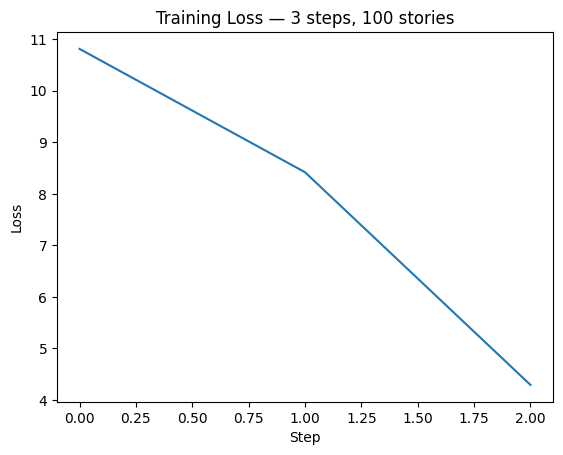

In [15]:
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss — 3 steps, 100 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [16]:
from pathlib import Path
import orbax

checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /content/small_checkpoint.orbax


In [17]:
import jax
import flax.nnx as nnx
from pathlib import Path


In [18]:
model = MiniGPT()

In [19]:
model

MiniGPT( # Param: 20,212,608 (80.9 MB)
  maxlen=128,
  embedding=TokenAndPositionEmbedding( # Param: 9,673,920 (38.7 MB)
    token_emb=Embed( # Param: 9,649,344 (38.6 MB)
      embedding=Param( # 9,649,344 (38.6 MB)
        value=Array(shape=(50257, 192), dtype=dtype('float32'))
      ),
      num_embeddings=50257,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      embedding_init=<function variance_scaling.<locals>.init at 0x785d890a72e0>,
      promote_dtype=<function promote_dtype at 0x785d88cfbba0>
    ),
    pos_emb=Embed( # Param: 24,576 (98.3 KB)
      embedding=Param( # 24,576 (98.3 KB)
        value=Array(shape=(128, 192), dtype=dtype('float32'))
      ),
      num_embeddings=128,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      embedding_init=<function variance_scaling.<locals>.init at 0x785d890a72e0>,
      promote_dtype=<function promote_dtype at 0x785d88cfbba0>
    )
  ),
  transformer_blocks=[TransformerBloc

In [20]:
import orbax
from orbax import checkpoint

from jax.sharding import SingleDeviceSharding

In [21]:
cpu_device = jax.devices('cpu')[0]
cpu_sharding = SingleDeviceSharding(cpu_device)

In [22]:
restore_args = jax.tree_util.tree_map(
    lambda _: checkpoint.ArrayRestoreArgs(sharding=cpu_sharding),
    nnx.state(model)
)

In [23]:
nnx.state(model)

State({
  'embedding': {
    'pos_emb': {
      'embedding': Param( # 24,576 (98.3 KB)
        value=Array([[ 0.05352228,  0.02541235, -0.06864465, ...,  0.0146625 ,
                 0.00328262, -0.04726132],
               [-0.08220372, -0.04515665, -0.00612232, ..., -0.09563749,
                -0.01843894,  0.01549728],
               [-0.06093907,  0.0177572 , -0.01647195, ..., -0.03995116,
                -0.01099424,  0.03832502],
               ...,
               [ 0.07915515,  0.05211703,  0.12390719, ..., -0.07260621,
                 0.03098172,  0.04544031],
               [-0.03015278,  0.15414171, -0.05988786, ..., -0.02824458,
                -0.07689138, -0.01760155],
               [-0.07330009,  0.00358137, -0.02108287, ...,  0.02033728,
                -0.00082093, -0.02600233]], dtype=float32)
      )
    },
    'token_emb': {
      'embedding': Param( # 9,649,344 (38.6 MB)
        value=Array([[ 0.00456231, -0.08050305,  0.0668545 , ...,  0.0371966 ,
              

In [24]:
checkpoint_path = Path.cwd() / "small_checkpoint.orbax"
checkpointer = orbax.checkpoint.PyTreeCheckpointer()

In [25]:
restored_state = checkpointer.restore(
    checkpoint_path,
    item=nnx.state(model),
    restore_args=restore_args)

nnx.update(model,restored_state)

In [26]:
def create_story(story_prompt, temperature, max_new_tokens):
    return generate_story(model, story_prompt, temperature, max_new_tokens)

In [28]:
create_story("Sivaranjani ", 0.2, 25)

'Sivaranjani !!!!!!!!!!!!!!!!!!!!!!!!!'

In [ ]:
import gradio as gr

demo = gr.Interface(
    fn=create_story,
    inputs=[
        gr.Textbox(label="Story Prompt"),
        gr.Slider(
            minimum=0, maximum=1.0, value=0.8, step=0.01, label="Temperature"
        ),
        gr.Slider(minimum=0, maximum=200, value=10, step=1, label="Max Tokens"
        )
    ],
    outputs=["text"]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1d4bf7bc7c38fb544.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
